## Weather Forecasting 


### Import Libraries, load and read the first few lines


In [61]:
import numpy as np

In [1]:
import pandas as pd

df = pd.read_csv(r"GlobalWeatherRepository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## Data Information

In [2]:
df.shape

(155336, 41)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155336 entries, 0 to 155335
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       155336 non-null  object 
 1   location_name                 155336 non-null  object 
 2   latitude                      155336 non-null  float64
 3   longitude                     155336 non-null  float64
 4   timezone                      155336 non-null  object 
 5   last_updated_epoch            155336 non-null  int64  
 6   last_updated                  155336 non-null  object 
 7   temperature_celsius           155336 non-null  float64
 8   temperature_fahrenheit        155336 non-null  float64
 9   condition_text                155336 non-null  object 
 10  wind_mph                      155336 non-null  float64
 11  wind_kph                      155336 non-null  float64
 12  wind_degree                   155336 non-nul

## Find Null Values

In [4]:
df.describe()

df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

## Check for Duplicates

In [5]:
df.duplicated().sum()


np.int64(0)

### Check for any repeating values in same location and same time 

In [6]:
df[df.duplicated(subset=["location_name", "last_updated"], keep=False)]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
125208,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00,32.2,90.0,Partly Cloudy,...,21.55,21.55,2,2,06:42 AM,06:19 PM,08:21 AM,08:58 PM,Waxing Crescent,6
125244,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00,32.2,90.0,Partly Cloudy,...,21.55,21.55,2,2,06:30 AM,06:54 PM,09:05 AM,09:14 PM,Waxing Crescent,8


## Inspect the repeating data

In [7]:
df[df.duplicated(subset=["location_name", "last_updated"], keep=False)].T

,125208,125244
country,Thailand,Thailand
location_name,Nan,Nan
latitude,18.7833,18.7833
longitude,100.7833,100.7833
timezone,Asia/Bangkok,Asia/Bangkok
last_updated_epoch,1771570800,1771570800
last_updated,2026-02-20 14:00,2026-02-20 14:00
temperature_celsius,32.2,32.2
temperature_fahrenheit,90.0,90.0
condition_text,Partly Cloudy,Partly Cloudy


In [8]:
duplicate_rows = df.loc[[125208, 125244]]

duplicate_rows.T[duplicate_rows.T[125208] != duplicate_rows.T[125244]]

,125208,125244
sunrise,06:42 AM,06:30 AM
sunset,06:19 PM,06:54 PM
moonrise,08:21 AM,09:05 AM
moonset,08:58 PM,09:14 PM
moon_illumination,6,8


### Sun and Moon timings are different so I will drop one entry and keep the first entry

In [9]:
df = df.drop_duplicates(
    subset=["location_name", "last_updated_epoch"],
    keep="first"
)

### Now check how many rows are left after deleting one

In [10]:
df.shape

(155335, 41)

### Now check most appeared locations in data

In [11]:
df["location_name"].value_counts().head(10)

location_name
Sanaa           800
Bujumbura       799
Kyiv            799
Tashkent        799
N'djamena       799
Dakar           799
Bern            799
Vatican City    799
Malabo          799
Asmara          799
Name: count, dtype: int64

### Check whether same location and same dates appear more than once 

In [15]:
df.duplicated(subset=["latitude", "longitude", "last_updated"]).sum()

np.int64(0)

## checked sum of null values again 

In [16]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

### Converted last_updated column to date_time to make it easy later for data modelling and forecasting

In [17]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

### Checking my conversion is successful, sorting last_updated column and checking that sorting has worked

In [19]:
df["last_updated"].dtype

dtype('<M8[ns]')

In [20]:
df["last_updated"].min(), df["last_updated"].max()

(Timestamp('2024-05-16 01:45:00'), Timestamp('2026-07-25 18:45:00'))

In [24]:
df["last_updated"].dt.year.value_counts()

last_updated
2025    71100
2024    44469
2026    39766
Name: count, dtype: int64

In [26]:
df = df.sort_values("last_updated")

In [30]:
df["last_updated"].is_monotonic_increasing

True

In [34]:
df["last_updated"].tail()

155330   2026-07-25 17:45:00
155331   2026-07-25 17:45:00
155332   2026-07-25 17:45:00
155333   2026-07-25 18:45:00
155334   2026-07-25 18:45:00
Name: last_updated, dtype: datetime64[ns]

In [33]:
df["last_updated"].head()


0   2024-05-16 01:45:00
1   2024-05-16 02:45:00
2   2024-05-16 02:45:00
3   2024-05-16 02:45:00
4   2024-05-16 02:45:00
Name: last_updated, dtype: datetime64[ns]

### Drop columns where measuring metrics are using different units for same data and make my data simple and easy for models  to understand 
 

In [37]:
df_clean = df.copy()

In [38]:
df_clean = df_clean.drop(columns=[
    "temperature_fahrenheit",
    "wind_mph",
    "pressure_in",
    "precip_in",
    "visibility_miles",
    "gust_mph",
    "feels_like_fahrenheit"
])

In [39]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155335 entries, 0 to 155334
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   last_updated                  155335 non-null  datetime64[ns]
 1   country                       155335 non-null  object        
 2   location_name                 155335 non-null  object        
 3   latitude                      155335 non-null  float64       
 4   longitude                     155335 non-null  float64       
 5   timezone                      155335 non-null  object        
 6   last_updated_epoch            155335 non-null  int64         
 7   temperature_celsius           155335 non-null  float64       
 8   condition_text                155335 non-null  object        
 9   wind_kph                      155335 non-null  float64       
 10  wind_degree                   155335 non-null  int64         
 11  wind_directio

### Checking for validity of metrics values under possible ranges found from statistical data 

## Temperature

In [ ]:
(df_clean["temperature_celsius"] < -50).sum(), (df_clean["temperature_celsius"] > 55).sum()


(np.int64(0), np.int64(1))

In [59]:
df_clean[df_clean["temperature_celsius"] > 55]

,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,condition_text,wind_kph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
137407,2026-04-24 18:30:00,Fiji Islands,Suva,-18.1333,178.4167,Pacific/Fiji,1777012200,79.3,Partly cloudy,16.2,...,4.25,5.95,1,1,06:18 AM,05:51 PM,12:53 PM,No moonset,First Quarter,43


In [62]:
df_clean.loc[df_clean["temperature_celsius"] < -50, "temperature_celsius"] = np.nan

In [65]:
df_clean["temperature_celsius"] = df_clean.groupby("location_name")["temperature_celsius"].transform(lambda x: x.fillna(x.median()))

## Feels like celsius

In [67]:
(df_clean["feels_like_celsius"] < -60).sum(), (df_clean["feels_like_celsius"] > 60).sum()


(np.int64(0), np.int64(1))

In [68]:
df_clean.loc[
    df_clean["feels_like_celsius"] > 60,
    "feels_like_celsius"
] = np.nan

df_clean["feels_like_celsius"] = df_clean.groupby("location_name")["feels_like_celsius"].transform(
    lambda x: x.fillna(x.median())
)

## Wind kph

In [45]:
(df_clean["wind_kph"] > 200).sum()


np.int64(4)

In [69]:
df_clean.loc[
    df_clean["wind_kph"] > 200,
    "wind_kph"
] = np.nan

df_clean["wind_kph"] = df_clean.groupby("location_name")["wind_kph"].transform(
    lambda x: x.fillna(x.median())
)

## Gust kph

In [46]:
(df_clean["gust_kph"] > 220).sum()


np.int64(3)

In [70]:
df_clean.loc[
    df_clean["gust_kph"] > 220,
    "gust_kph"
] = np.nan

df_clean["gust_kph"] = df_clean.groupby("location_name")["gust_kph"].transform(
    lambda x: x.fillna(x.median())
)

## Pressure milibar

In [47]:
(df_clean["pressure_mb"] < 850).sum(), (df_clean["pressure_mb"] > 1100).sum()


(np.int64(0), np.int64(2))

In [71]:
df_clean.loc[
    (df_clean["pressure_mb"] < 850) |
    (df_clean["pressure_mb"] > 1100),
    "pressure_mb"
] = np.nan

df_clean["pressure_mb"] = df_clean.groupby("location_name")["pressure_mb"].transform(
    lambda x: x.fillna(x.median())
)

## Precipitation

In [48]:
(df_clean["precip_mm"] > 500).sum()


np.int64(0)

## Humidity

In [49]:
(df_clean["humidity"] < 0).sum(), (df_clean["humidity"] > 100).sum()


(np.int64(0), np.int64(0))

## Visibility km

In [50]:
(df_clean["visibility_km"] < 0).sum(), (df_clean["visibility_km"] > 100).sum()


(np.int64(0), np.int64(0))

## UV Index

In [51]:
(df_clean["uv_index"] < 0).sum(), (df_clean["uv_index"] > 20).sum()


(np.int64(0), np.int64(0))

## Air quality PM 2.5


In [52]:
(df_clean["air_quality_PM2.5"] > 500).sum()


np.int64(86)

In [72]:
df_clean[df_clean["air_quality_PM2.5"] > 500][
    ["country","location_name","last_updated","air_quality_PM2.5"]
]

,country,location_name,last_updated,air_quality_PM2.5
82,Chile,Santiago,2024-05-16 10:00:00,714.100
556,Indonesia,Jakarta,2024-05-17 23:00:00,798.500
604,Chile,Santiago,2024-05-18 10:30:00,554.700
984,Chile,Santiago,2024-05-20 10:30:00,502.100
1334,Indonesia,Jakarta,2024-05-21 21:45:00,874.900
...,...,...,...,...
51571,Saudi Arabia,Riyadh,2025-02-06 13:15:00,611.610
51775,Saudi Arabia,Riyadh,2025-02-07 13:30:00,553.150
55290,Saudi Arabia,Riyadh,2025-02-25 13:00:00,639.175
68905,Saudi Arabia,Riyadh,2025-05-06 12:00:00,621.970


In [73]:
df_clean[df_clean["air_quality_PM2.5"] > 500][
    ["location_name","air_quality_PM2.5","air_quality_PM10","wind_kph","condition_text"]
]

,location_name,air_quality_PM2.5,air_quality_PM10,wind_kph,condition_text
82,Santiago,714.100,873.40,6.8,Sunny
556,Jakarta,798.500,1002.20,3.6,Mist
604,Santiago,554.700,682.10,3.6,Mist
984,Santiago,502.100,565.70,20.2,Mist
1334,Jakarta,874.900,1072.80,9.0,Mist
...,...,...,...,...,...
51571,Riyadh,611.610,5899.28,28.1,Partly cloudy
51775,Riyadh,553.150,6037.29,20.5,Overcast
55290,Riyadh,639.175,-1848.15,21.6,Overcast
68905,Riyadh,621.970,5623.63,23.4,Overcast


## Air quality PM 10


In [ ]:
(df_clean["air_quality_PM10"] > 1000).sum()


np.int64(481)

In [ ]:
df_clean.loc[
    df_clean["air_quality_PM10"] < 0,
    "air_quality_PM10"
] = np.nan

In [75]:
df_clean["air_quality_PM10"] = df_clean.groupby("location_name")["air_quality_PM10"].transform(
    lambda x: x.fillna(x.median())
)

## Air quality levels

### Carbon Monoxide

In [ ]:

(df_clean["air_quality_Carbon_Monoxide"] > 10000).sum()


np.int64(121)

In [76]:
df_clean[df_clean["air_quality_Carbon_Monoxide"] > 10000][
    ["country","location_name","last_updated",
     "air_quality_Carbon_Monoxide",
     "air_quality_PM2.5",
     "air_quality_PM10"]
]

,country,location_name,last_updated,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10
361,Indonesia,Jakarta,2024-05-16 21:00:00,19653.301,492.500,621.500
556,Indonesia,Jakarta,2024-05-17 23:00:00,24566.699,798.500,1002.200
754,Indonesia,Jakarta,2024-05-18 21:30:00,13565.100,278.200,376.600
943,Indonesia,Jakarta,2024-05-19 21:15:00,11322.000,244.700,319.000
1138,Indonesia,Jakarta,2024-05-20 21:45:00,22644.000,498.600,647.900
...,...,...,...,...,...,...
94875,Indonesia,Jakarta,2025-09-16 15:00:00,10073.200,230.880,233.470
95654,Indonesia,Jakarta,2025-09-20 14:45:00,12724.300,310.060,310.985
96046,Indonesia,Jakarta,2025-09-22 15:00:00,12469.000,280.830,280.830
96432,Indonesia,Jakarta,2025-09-24 15:00:00,10776.200,268.805,271.395


In [77]:
df_clean.loc[
    df_clean["air_quality_Carbon_Monoxide"] > 10000,
    "air_quality_Carbon_Monoxide"
] = np.nan

df_clean["air_quality_Carbon_Monoxide"] = df_clean.groupby("location_name")["air_quality_Carbon_Monoxide"].transform(
    lambda x: x.fillna(x.median())
)

### Ozone

In [55]:
(df_clean["air_quality_Ozone"] > 500).sum()


np.int64(0)

### Nitrogen Dioxide

In [56]:
(df_clean["air_quality_Nitrogen_dioxide"] > 500).sum()


np.int64(0)

### Sulpher Dioxide

In [ ]:
(df_clean["air_quality_Sulphur_dioxide"] > 500).sum()

np.int64(1)

In [ ]:
df_clean[df_clean["air_quality_Sulphur_dioxide"] > 500][
    ["country","location_name","last_updated",
     "air_quality_Sulphur_dioxide",
     "air_quality_PM2.5",
     "air_quality_PM10"]
]

,country,location_name,last_updated,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
46887,Egypt,Cairo,2025-01-13 12:45:00,521.33,97.31,129.315


In [79]:
df_clean[["air_quality_PM10","air_quality_PM2.5"]].isna().sum()

air_quality_PM10     0
air_quality_PM2.5    0
dtype: int64

## Final Data Check 

In [80]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

# Check duplicates
df_clean.duplicated().sum()

# Check data types
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155335 entries, 0 to 155334
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   last_updated                  155335 non-null  datetime64[ns]
 1   country                       155335 non-null  object        
 2   location_name                 155335 non-null  object        
 3   latitude                      155335 non-null  float64       
 4   longitude                     155335 non-null  float64       
 5   timezone                      155335 non-null  object        
 6   last_updated_epoch            155335 non-null  int64         
 7   temperature_celsius           155335 non-null  float64       
 8   condition_text                155335 non-null  object        
 9   wind_kph                      155335 non-null  float64       
 10  wind_degree                   155335 non-null  int64         
 11  wind_directio

## Save my clean dataset 

In [82]:
df_clean.to_csv("weather_forecasting_cleaned_dataset.csv", index=False)

# EDA

## Read my clean data CSV to start the analysis

In [88]:
weather_df = pd.read_csv("weather_forecasting_cleaned_dataset.csv")

In [90]:
list(weather_df.columns)

['last_updated',
 'country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'temperature_celsius',
 'condition_text',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'precip_mm',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'visibility_km',
 'uv_index',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

### Unique Countries and locations 

In [ ]:
weather_df["country"].nunique()

211

In [92]:
weather_df["location_name"].nunique()

268

In [93]:
weather_df["location_name"].value_counts().head(5)

location_name
Sanaa       800
Tashkent    799
Dakar       799
Tokyo       799
Baghdad     799
Name: count, dtype: int64

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns


## Data Visualization

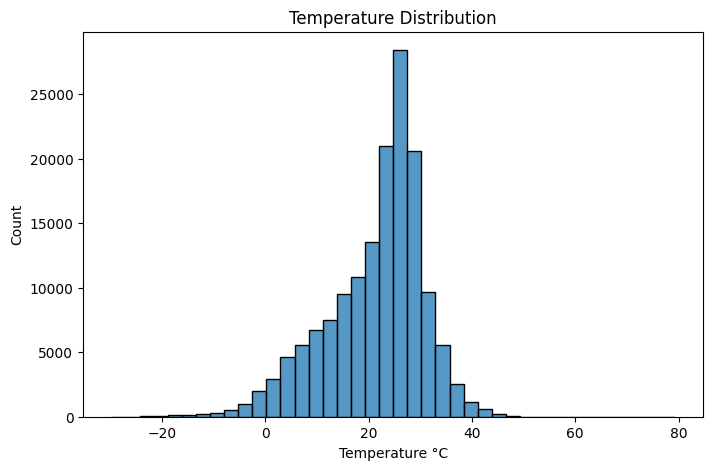

In [109]:
plt.figure(figsize=(8,5))

sns.histplot(
    weather_df["temperature_celsius"],
    bins=40
)

plt.xlabel("Temperature °C")
plt.title("Temperature Distribution")
plt.show()

In [97]:
weather_df["temperature_celsius"].describe()

count    155335.000000
mean         21.382728
std           9.464164
min         -29.800000
25%          16.100000
50%          23.700000
75%          27.900000
max          79.300000
Name: temperature_celsius, dtype: float64

In [110]:
weather_df["temperature_celsius"].max()

np.float64(79.3)

In [111]:
weather_df.loc[
    weather_df["temperature_celsius"].idxmax()
]

last_updated                    2026-04-24 18:30:00
country                                Fiji Islands
location_name                                  Suva
latitude                                   -18.1333
longitude                                  178.4167
timezone                               Pacific/Fiji
last_updated_epoch                       1777012200
temperature_celsius                            79.3
condition_text                        Partly cloudy
wind_kph                                       16.2
wind_degree                                     121
wind_direction                                  ESE
pressure_mb                                  1013.0
precip_mm                                      0.99
humidity                                          7
cloud                                            50
feels_like_celsius                             27.0
visibility_km                                  10.0
uv_index                                        0.0
gust_kph    

## Outliers detection and encoding

In [112]:
weather_df.loc[
    weather_df["temperature_celsius"] > 55,
    "temperature_celsius"
] = None

In [113]:
weather_df["temperature_celsius"] = (
    weather_df.groupby("location_name")["temperature_celsius"]
    .transform(lambda x: x.fillna(x.median()))
)

In [115]:
weather_df["temperature_celsius"].describe()

count    155335.000000
mean         21.382376
std           9.463027
min         -29.800000
25%          16.100000
50%          23.700000
75%          27.900000
max          49.200000
Name: temperature_celsius, dtype: float64

In [116]:
weather_df.loc[
    weather_df["temperature_celsius"] < -20,
    ["country","location_name","temperature_celsius"]
]

,country,location_name,temperature_celsius
37233,Mongolia,Ulaanbaatar,-20.1
39571,Mongolia,Ulaanbaatar,-21.9
40137,Kazakhstan,Astana,-20.7
40746,Mongolia,Ulaanbaatar,-22.9
40940,Mongolia,Ulaanbaatar,-20.1
...,...,...,...
126827,Kazakhstan,Astana,-21.7
126839,Russia,Chi-Chi-Erh,-20.7
127020,Kazakhstan,Astana,-23.9
127424,Russia,Chi-Chi-Erh,-20.5


In [114]:
weather_df.groupby("location_name")["temperature_celsius"].mean().sort_values()

location_name
Chi-Chi-Erh            -12.490244
S-Chanf                  0.534000
Reykjavik                3.738947
Ulaanbaatar              5.101506
Ottawa                   5.844095
                          ...    
Doha                    32.632412
Krasnyy Turkmenistan    37.800000
Morocco City            40.300000
Kuwait                  44.400000
Ar Riyadh               45.000000
Name: temperature_celsius, Length: 268, dtype: float64

In [99]:
weather_df.groupby("location_name")["temperature_celsius"].mean().sort_values(ascending=False).head(10)

location_name
Ar Riyadh               45.000000
Kuwait                  44.400000
Morocco City            40.300000
Krasnyy Turkmenistan    37.800000
Doha                    32.632412
Abu Dhabi               32.413158
Phnom Penh              32.084403
Bangkok                 32.005270
Muscat                  31.895489
Rangoon                 31.616612
Name: temperature_celsius, dtype: float64

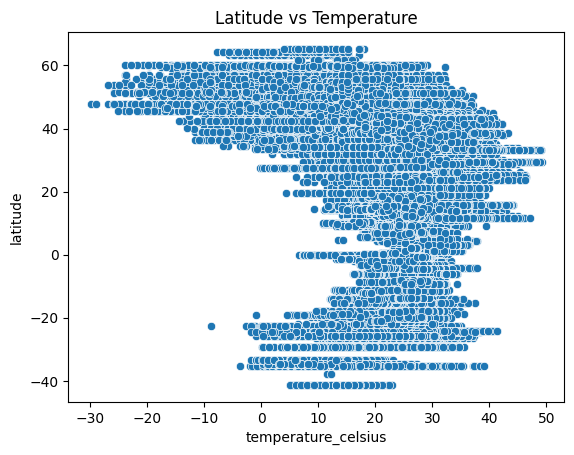

In [121]:
sns.scatterplot(
    data=weather_df,
    x="temperature_celsius", 
    y="latitude",
)

plt.title("Latitude vs Temperature")
plt.show()

In [101]:
weather_df.groupby("location_name")["precip_mm"].mean().sort_values(ascending=False).head(10)

location_name
Ivory Ivory Ban    1.550000
Abazu              1.360000
Melbourne          1.220000
Palau              1.025000
Vientiane          1.005000
Achelap            0.831250
Pathein            0.769375
Bafoussam          0.663333
Laos               0.620791
Namawbin           0.610714
Name: precip_mm, dtype: float64

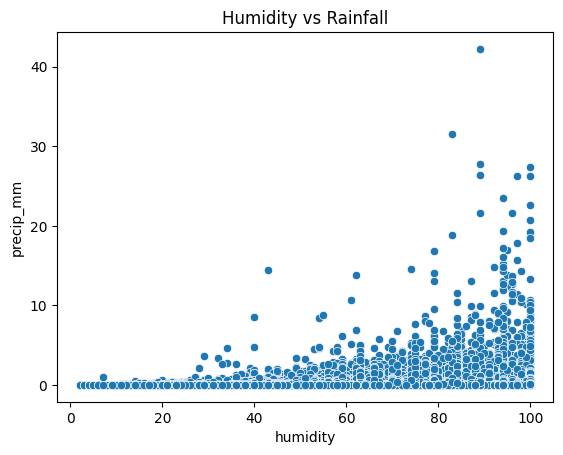

In [102]:
sns.scatterplot(
    data=weather_df,
    x="humidity",
    y="precip_mm"
)

plt.title("Humidity vs Rainfall")
plt.show()

In [122]:
numeric_cols = weather_df.select_dtypes(
    include="number"
)

corr = numeric_cols.corr()

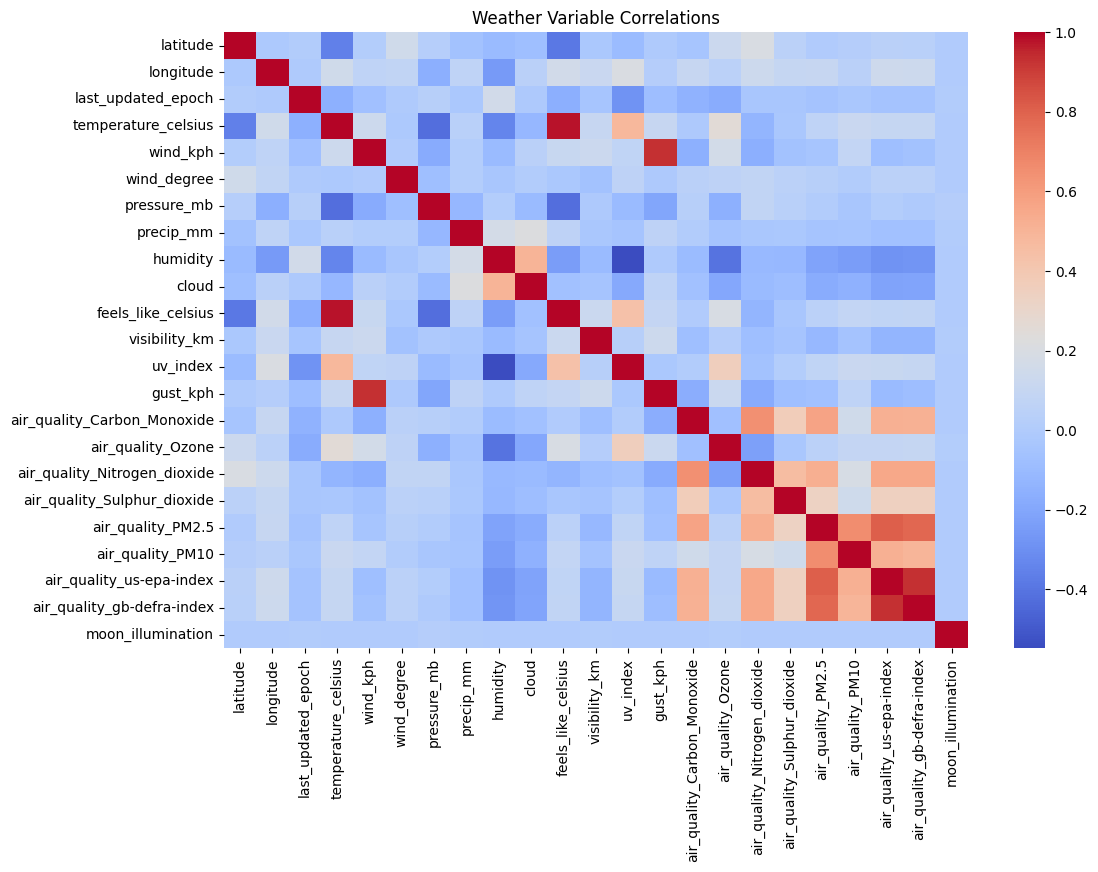

In [123]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Weather Variable Correlations")
plt.show()

In [105]:
weather_df.groupby("location_name")["air_quality_PM2.5"].mean().sort_values(ascending=False).head(10)

location_name
Kuwait         176.700000
Santiago       140.757931
Jakarta        135.793766
Riyadh         134.818683
Beijing        122.614132
New Delhi      108.607698
Kuwait City     91.452613
Hanoi           72.723852
Nouakchott      66.875947
Dhaka           65.918338
Name: air_quality_PM2.5, dtype: float64

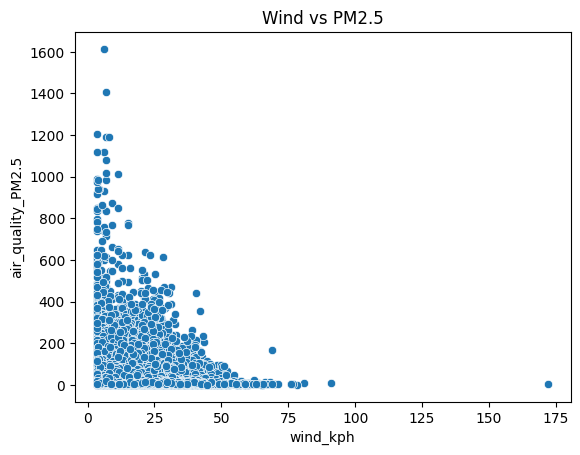

In [106]:
sns.scatterplot(
    data=weather_df,
    x="wind_kph",
    y="air_quality_PM2.5"
)

plt.title("Wind vs PM2.5")
plt.show()

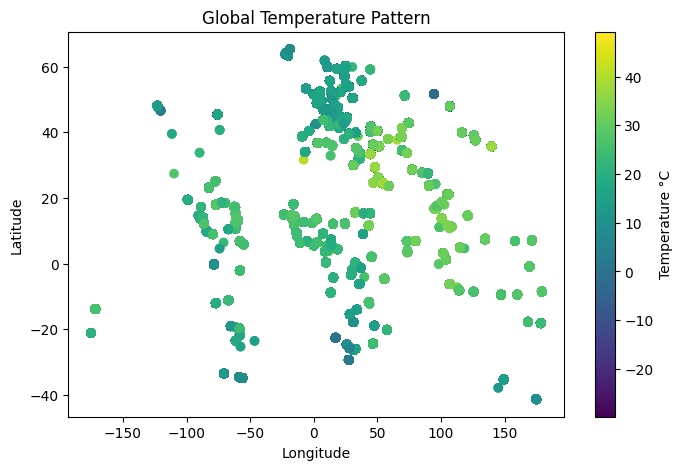

In [124]:
plt.figure(figsize=(8,5))

plt.scatter(
    weather_df["longitude"],
    weather_df["latitude"],
    c=weather_df["temperature_celsius"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Temperature Pattern")

plt.colorbar(label="Temperature °C")

plt.show()

In [129]:
weather_df[
    (weather_df["latitude"] > 90) |
    (weather_df["latitude"] < -90)
]

,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,condition_text,wind_kph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


In [128]:
weather_df[
    (weather_df["longitude"] > 180) |
    (weather_df["longitude"] < -180)
]

,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,condition_text,wind_kph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


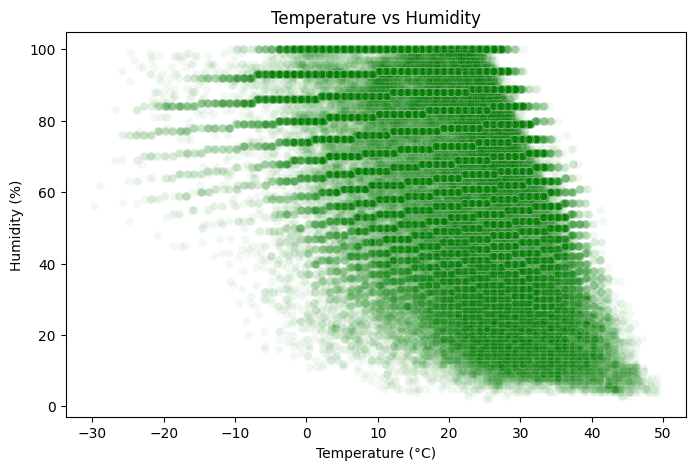

In [137]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=weather_df,
    x="temperature_celsius",
    y="humidity",
    color="green",
    alpha=0.05
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")

plt.show()

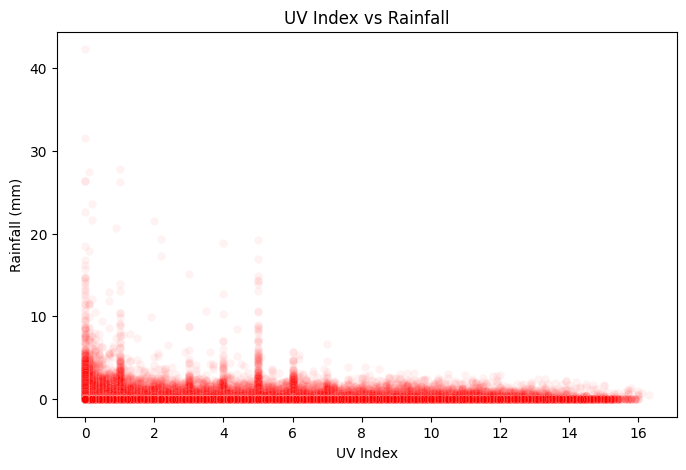

In [135]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=weather_df,
    x="uv_index",
    y="precip_mm",
    color="red",
    alpha=0.05
)

plt.xlabel("UV Index")
plt.ylabel("Rainfall (mm)")
plt.title("UV Index vs Rainfall")

plt.show()

## Time Series Analysis

In [138]:
weather_df["last_updated"] = pd.to_datetime(weather_df["last_updated"])

In [139]:
weather_df = weather_df.sort_values("last_updated")

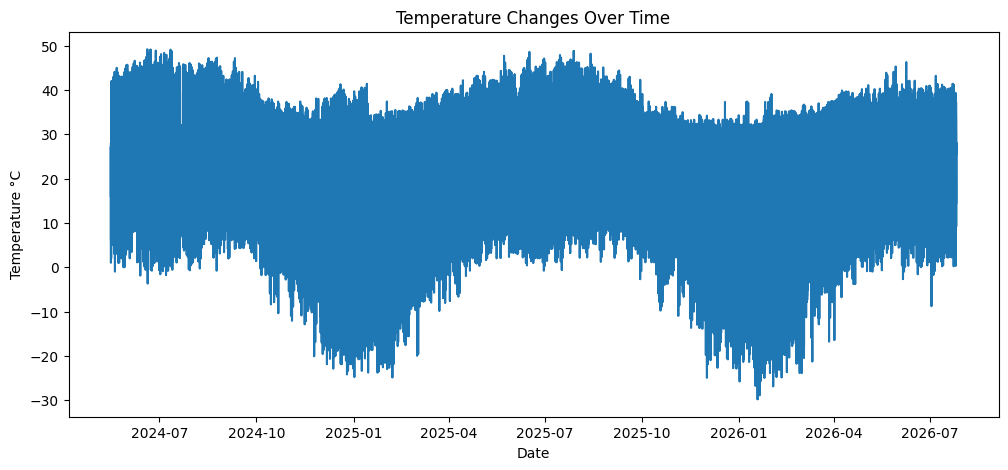

In [140]:
plt.figure(figsize=(12,5))

plt.plot(
    weather_df["last_updated"],
    weather_df["temperature_celsius"]
)

plt.xlabel("Date")
plt.ylabel("Temperature °C")
plt.title("Temperature Changes Over Time")

plt.show()

In [141]:
weather_df["date"] = weather_df["last_updated"].dt.date

In [142]:
daily_temp = (
    weather_df
    .groupby("date")["temperature_celsius"]
    .mean()
)

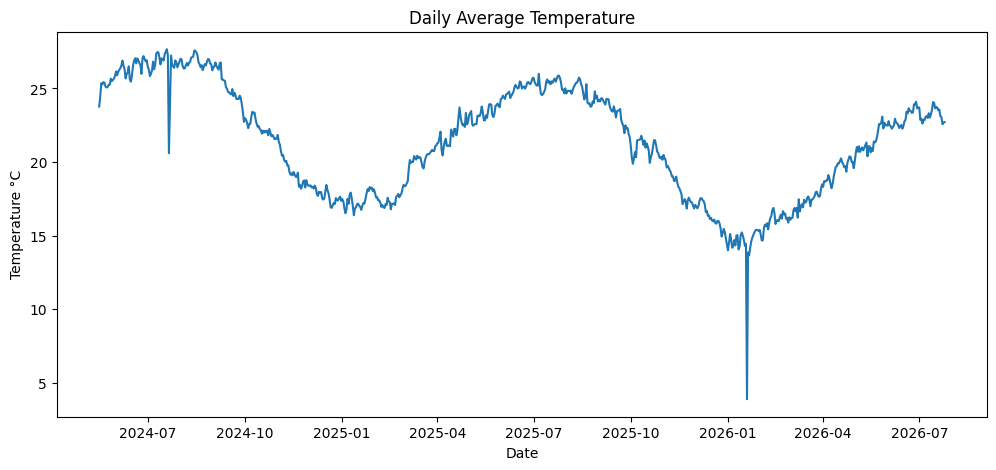

In [143]:
plt.figure(figsize=(12,5))

daily_temp.plot()

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature °C")

plt.show()

In [144]:
weather_df["month"] = weather_df["last_updated"].dt.month

In [145]:
season_temp = (
    weather_df
    .groupby("month")["temperature_celsius"]
    .mean()
)

season_temp

month
1     16.072073
2     16.712515
3     18.696641
4     20.706111
5     22.961891
6     24.791750
7     25.194101
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64

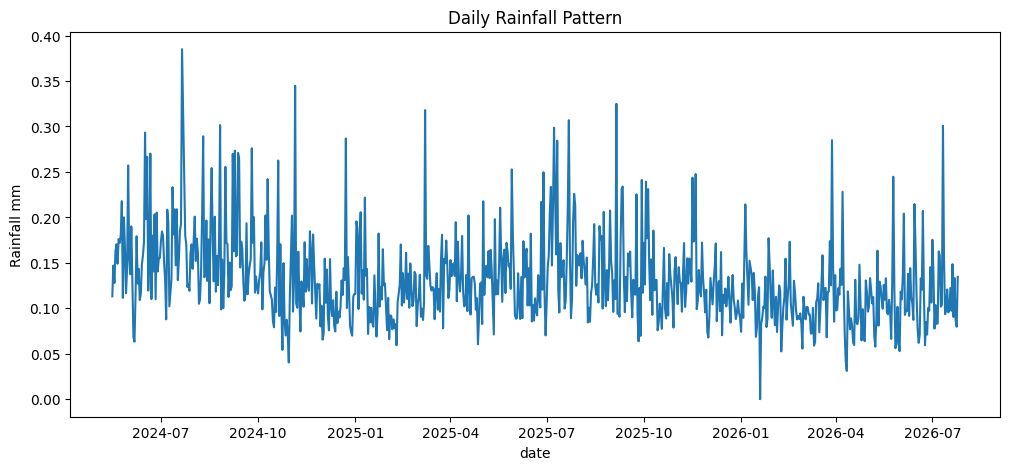

In [146]:
daily_rain = (
    weather_df
    .groupby("date")["precip_mm"]
    .mean()
)

daily_rain.plot(figsize=(12,5))

plt.title("Daily Rainfall Pattern")
plt.ylabel("Rainfall mm")

plt.show()

In [148]:
Q1 = weather_df["temperature_celsius"].quantile(0.25)
Q3 = weather_df["temperature_celsius"].quantile(0.75)

IQR = Q3 - Q1

temp_anomalies = weather_df[
    (weather_df["temperature_celsius"] < Q1 - 1.5*IQR) |
    (weather_df["temperature_celsius"] > Q3 + 1.5*IQR)
]

temp_anomalies.head()

,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,condition_text,wind_kph,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,date,month
3051,2024-05-30 16:45:00,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717076700,45.6,Sunny,6.8,...,2,3,04:49 AM,06:42 PM,No moonrise,11:15 AM,Last Quarter,58,2024-05-30,5
3245,2024-05-31 17:15:00,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717164900,45.7,Sunny,3.6,...,2,4,04:49 AM,06:43 PM,12:33 AM,12:19 PM,Waning Crescent,47,2024-05-31,5
4408,2024-06-06 17:00:00,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717682400,45.9,Sunny,9.0,...,3,5,04:48 AM,06:46 PM,04:14 AM,07:00 PM,New Moon,0,2024-06-06,6
4601,2024-06-07 17:00:00,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717768800,46.6,Partly cloudy,16.9,...,2,2,04:48 AM,06:46 PM,05:08 AM,08:03 PM,Waxing Crescent,0,2024-06-07,6
5570,2024-06-12 17:15:00,Qatar,Doha,25.29,51.53,Asia/Qatar,1718201700,46.2,Sunny,11.2,...,3,5,04:43 AM,06:25 PM,09:58 AM,11:09 PM,Waxing Crescent,29,2024-06-12,6


In [149]:
pm25_anomalies = weather_df[
    weather_df["air_quality_PM2.5"] > 
    weather_df["air_quality_PM2.5"].quantile(0.99)
]

pm25_anomalies[
    ["country","location_name","last_updated","air_quality_PM2.5"]
]

,country,location_name,last_updated,air_quality_PM2.5
16,Chile,Santiago,2024-05-16 04:45:00,211.1
69,Angola,Luanda,2024-05-16 09:45:00,183.4
82,Chile,Santiago,2024-05-16 10:00:00,714.1
235,Indonesia,Jakarta,2024-05-16 15:45:00,196.1
361,Indonesia,Jakarta,2024-05-16 21:00:00,492.5
...,...,...,...,...
152961,India,New Delhi,2026-07-13 11:30:00,161.6
153123,Kuwait,Kuwait City,2026-07-14 09:15:00,161.1
153155,India,New Delhi,2026-07-14 11:30:00,183.5
153934,India,New Delhi,2026-07-18 11:15:00,170.4


In [150]:
weather_df[
    weather_df["air_quality_PM2.5"] > 150
]["location_name"].value_counts()

location_name
Jakarta           271
Riyadh            266
Beijing           234
New Delhi         173
Santiago          146
Kuwait City        95
Nouakchott         77
Dhaka              70
Hanoi              53
Pretoria           28
Abuja              26
N'djamena          25
Ouagadougou        18
Moscow             14
Kuala Lumpur       12
Luanda             12
Juba               12
Manama             12
Islamabad          11
National           11
Bissau              9
Ulaanbaatar         8
Seoul               7
Guatemala City      7
Khartoum            7
Baghdad             6
Porto-Novo          6
Bangkok             6
Banjul              5
Dakar               5
Abu Dhabi           5
Bucharest           3
Tehran              3
Aurora              3
Warsaw              3
Doha                2
Manila              2
Belgrade            2
Bras                2
Bamako              2
Kathmandu           2
Ban Lom             2
Harare              1
Baku                1
Kuwait            

In [151]:
country_temp = (
    weather_df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values()
)

country_temp

country
Mongolia          5.101506
Iceland           5.790327
Canada            5.844095
Norway            8.320494
Andorra           8.931078
                   ...    
Qatar            32.632412
Турция           34.000000
Turkménistan     37.800000
Marrocos         40.300000
Saudi Arabien    45.000000
Name: temperature_celsius, Length: 211, dtype: float64

In [152]:
country_rain = (
    weather_df.groupby("country")["precip_mm"]
    .mean()
    .sort_values()
)

country_rain

country
Estonie                             0.000000
Marrocos                            0.000000
Komoren                             0.000000
Mexique                             0.000000
Libya                               0.000000
                                      ...   
USA United States of America        0.530000
Malaysia                            0.586976
Lao People's Democratic Republic    1.005000
Malásia                             1.550000
Letonia                             1.830000
Name: precip_mm, Length: 211, dtype: float64

# Weather Forecasting

## Baseline model

In [167]:
baseline_predictions = y_test.shift(1)

# remove first missing value
baseline_predictions = baseline_predictions.fillna(y_train.iloc[-1])

In [168]:
baseline_predictions = y_test.shift(1)

# remove first missing value
baseline_predictions = baseline_predictions.fillna(y_train.iloc[-1])

In [169]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline MAE: 7.7248366433836555
Baseline RMSE: 10.436823552500611
Baseline R2: -0.36078084384061304


## Random Forest Model

In [153]:
weather_df = weather_df.sort_values("last_updated")

In [154]:
weather_df["hour"] = weather_df["last_updated"].dt.hour
weather_df["month"] = weather_df["last_updated"].dt.month

In [155]:
features = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "cloud",
    "uv_index",
    "latitude",
    "longitude",
    "hour",
    "month"
]

X = weather_df[features]

y = weather_df["temperature_celsius"]

In [156]:
split = int(len(weather_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [158]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [159]:
predictions = model.predict(X_test)

In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE = mean_absolute_error(y_test, predictions)

MSE = mean_squared_error(y_test, predictions)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test, predictions)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R2:", R2)

MAE: 2.2784380173992993
RMSE: 3.2235068719683944
R2: 0.8701898340147706


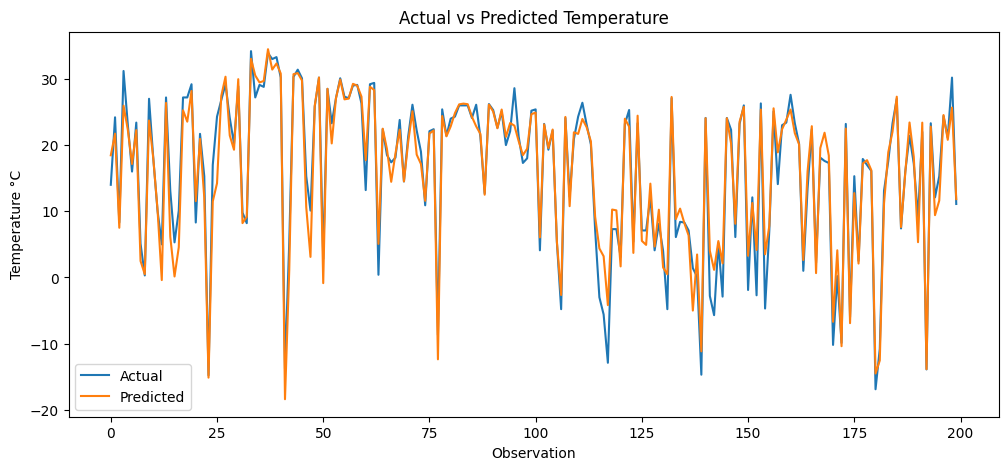

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.xlabel("Observation")
plt.ylabel("Temperature °C")
plt.title("Actual vs Predicted Temperature")

plt.legend()
plt.show()

## XGBoost Model

In [163]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   --- ------------------------------------ 5.5/69.5 MB 30.2 MB/s eta 0:00:03
   ------ --------------------------------- 11.0/69.5 MB 28.8 MB/s eta 0:00:03
   -------- ------------------------------- 14.7/69.5 MB 24.0 MB/s eta 0:00:03
   ---------- ----------------------------- 17.8/69.5 MB 22.3 MB/s eta 0:00:03
   ----------- ---------------------------- 19.4/69.5 MB 19.7 MB/s eta 0:00:03
   ------------- -------------------------- 23.6/69.5 MB 18.8 MB/s eta 0:00:03
   ----------------- ---------------------- 29.6/69.5 MB 20.2 MB/s eta 0:00:02
   -------------------- ------------------- 35.4/69.5 MB 21.1 MB/s eta 0:00:02
   ----------------------- ---------------- 41.7/69.5 MB 22.1 MB/s eta 0:00:02
   --------------------------- ------------ 47.7/69.5 MB 22.8 MB/s eta 0:00:01
   ------------------------------- -------- 54.0/69.5 MB 23.3 MB/s eta 0:00:01
   ---------------------------------- ----- 59.5/69.5 MB 23.6 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [164]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

# Evaluate XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results")
print("----------------")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


# Compare with Random Forest
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        MAE,
        xgb_mae
    ],
    "RMSE": [
        RMSE,
        xgb_rmse
    ],
    "R2": [
        R2,
        xgb_r2
    ]
})

print("\nModel Comparison")
results

XGBoost Results
----------------
MAE: 2.325988633929874
RMSE: 3.1923047563895532
R2: 0.87269068117207

Model Comparison


,Model,MAE,RMSE,R2
0,Random Forest,2.278438,3.223507,0.870190
1,XGBoost,2.325989,3.192305,0.872691


In [165]:
ensemble_predictions = (
    predictions + xgb_predictions
) / 2

In [170]:
ensemble_mae = mean_absolute_error(
    y_test,
    ensemble_predictions
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ensemble_predictions
    )
)

ensemble_r2 = r2_score(
    y_test,
    ensemble_predictions
)

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)
print("Ensemble R2:", ensemble_r2)

Ensemble MAE: 2.155285706896892
Ensemble RMSE: 3.002699569355008
Ensemble R2: 0.8873645060781856


# results

In [171]:

final_results = pd.DataFrame({
    "Model": [
        "Baseline (Previous Temperature)",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],
    "MAE": [
        baseline_mae,
        MAE,
        xgb_mae,
        ensemble_mae
    ],
    "RMSE": [
        baseline_rmse,
        RMSE,
        xgb_rmse,
        ensemble_rmse
    ],
    "R2": [
        baseline_r2,
        R2,
        xgb_r2,
        ensemble_r2
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Baseline (Previous Temperature),7.724837,10.436824,-0.360781
1,Random Forest,2.278438,3.223507,0.870190
2,XGBoost,2.325989,3.192305,0.872691
3,Ensemble,2.155286,3.002700,0.887365
